# Food Delivery Order Status Prediction

This notebook builds a machine learning classification model that predicts whether a food delivery order will be **Delivered**, **Cancelled**, or **Delayed**. It includes data inspection, feature engineering, preprocessing, model comparison, evaluation, and model export for the Streamlit demo.

In [8]:
# Import the libraries used throughout the project.
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [9]:
# Load the CSV. Put the CSV beside this notebook for easy portability.
DATA_PATH = Path('daily_food_delivery_orders.csv')
if not DATA_PATH.exists():
    # Fallback for the original location supplied with the project.
    DATA_PATH = Path(r'D:/Code Projects/MachineLearning Project/daily_food_delivery_orders.csv')

df = pd.read_csv(DATA_PATH)
print(f'Rows: {len(df):,} | Columns: {len(df.columns)}')
display(df.head())

Rows: 2,600 | Columns: 10


,order_id,order_date,customer_age,restaurant_type,order_value,delivery_distance_km,delivery_time_minutes,payment_method,delivery_partner_rating,order_status
0,1,2024-11-05,62,Indian,497.51,11.07,79,UPI,3.9,Cancelled
1,2,2024-08-20,35,Bakery,232.32,5.83,69,Wallet,2.7,Cancelled
2,3,2024-02-28,34,Italian,540.82,3.61,70,Wallet,3.4,Cancelled
3,4,2024-05-26,65,Cafe,1197.99,3.66,18,Card,4.6,Cancelled
4,5,2024-09-21,40,Indian,947.03,12.08,57,UPI,4.9,Delayed


<class 'pandas.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 2600 non-null   int64  
 1   order_date               2600 non-null   str    
 2   customer_age             2600 non-null   int64  
 3   restaurant_type          2600 non-null   str    
 4   order_value              2600 non-null   float64
 5   delivery_distance_km     2600 non-null   float64
 6   delivery_time_minutes    2600 non-null   int64  
 7   payment_method           2600 non-null   str    
 8   delivery_partner_rating  2600 non-null   float64
 9   order_status             2600 non-null   str    
dtypes: float64(3), int64(3), str(4)
memory usage: 277.1 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,2600.0,NaN,NaN,NaN,1300.5,750.699674,1.0,650.75,1300.5,1950.25,2600.0
order_date,2600,366,2024-11-27,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_age,2600.0,NaN,NaN,NaN,41.492308,13.977196,18.0,29.0,41.0,54.0,65.0
restaurant_type,2600,6,Bakery,454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_value,2600.0,NaN,NaN,NaN,670.293873,300.767326,150.9,406.4025,667.58,927.48,1199.78
delivery_distance_km,2600.0,NaN,NaN,NaN,7.8868,4.211332,0.5,4.2075,7.965,11.59,14.99
delivery_time_minutes,2600.0,NaN,NaN,NaN,51.748462,21.98754,15.0,32.0,51.0,70.0,90.0
payment_method,2600,4,UPI,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery_partner_rating,2600.0,NaN,NaN,NaN,3.749577,0.721153,2.5,3.1,3.8,4.4,5.0
order_status,2600,3,Delivered,895,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values by column:


,missing_values
order_id,0
order_date,0
customer_age,0
restaurant_type,0
order_value,0
delivery_distance_km,0
delivery_time_minutes,0
payment_method,0
delivery_partner_rating,0
order_status,0


C:\Users\Dell\AppData\Local\Temp\ipykernel_668\855116256.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='order_status', order=df['order_status'].value_counts().index, palette='viridis')


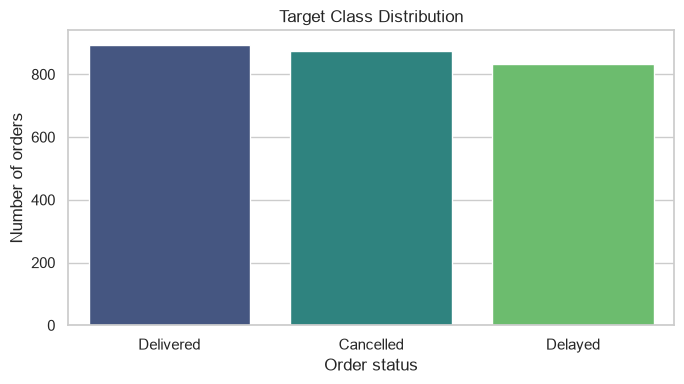

In [10]:
# Basic data-quality checks. The supplied dataset has complete rows.
display(df.info())
display(df.describe(include='all').T)
print('Missing values by column:')
display(df.isna().sum().to_frame('missing_values'))

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='order_status', order=df['order_status'].value_counts().index, palette='viridis')
plt.title('Target Class Distribution')
plt.xlabel('Order status')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

## Feature engineering

`order_id` is an identifier, so it is excluded. The date is converted into meaningful calendar features. `delivery_time_minutes` is intentionally retained as an input because this project demonstrates prediction from an order record that includes the observed delivery-time estimate.

In [11]:
def prepare_features(data: pd.DataFrame) -> pd.DataFrame:
    # Work on a copy so the original dataframe remains unchanged.
    features = data.copy()
    features['order_date'] = pd.to_datetime(features['order_date'])
    features['order_month'] = features['order_date'].dt.month
    features['order_day_of_week'] = features['order_date'].dt.dayofweek
    features['is_weekend'] = (features['order_day_of_week'] >= 5).astype(int)
    return features.drop(columns=['order_id', 'order_date'], errors='ignore')

X = prepare_features(df.drop(columns=['order_status']))
y = df['order_status']
X.head()

,customer_age,restaurant_type,order_value,delivery_distance_km,delivery_time_minutes,payment_method,delivery_partner_rating,order_month,order_day_of_week,is_weekend
0,62,Indian,497.51,11.07,79,UPI,3.9,11,1,0
1,35,Bakery,232.32,5.83,69,Wallet,2.7,8,1,0
2,34,Italian,540.82,3.61,70,Wallet,3.4,2,2,0
3,65,Cafe,1197.99,3.66,18,Card,4.6,5,6,1
4,40,Indian,947.03,12.08,57,UPI,4.9,9,5,1


In [12]:
# Split the data with stratification so each class is represented fairly.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

categorical_features = ['restaurant_type', 'payment_method']
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced'),
}

results = []
pipelines = {}
for name, estimator in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', estimator)])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    results.append({'Model': name, 'Accuracy': accuracy_score(y_test, predictions)})
    pipelines[name] = pipeline

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
display(results_df)

,Model,Accuracy
1,Random Forest,0.323077
0,Logistic Regression,0.313462


Best model: Random Forest
              precision    recall  f1-score   support

   Cancelled       0.34      0.35      0.35       175
     Delayed       0.30      0.30      0.30       166
   Delivered       0.33      0.32      0.32       179

    accuracy                           0.32       520
   macro avg       0.32      0.32      0.32       520
weighted avg       0.32      0.32      0.32       520



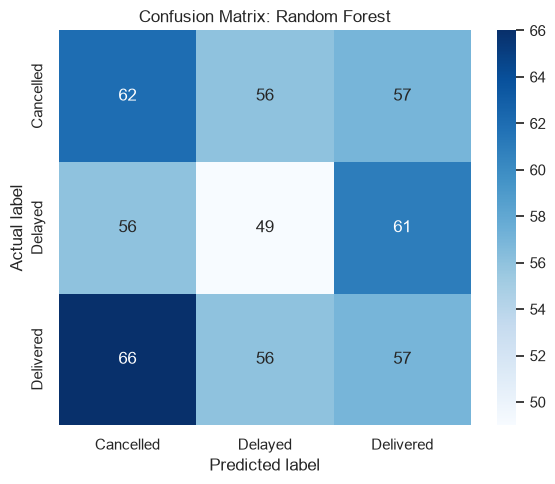

In [13]:
# Select the best model and inspect class-level performance.
best_model_name = results_df.iloc[0]['Model']
best_pipeline = pipelines[best_model_name]
y_pred = best_pipeline.predict(X_test)

print(f'Best model: {best_model_name}')
print(classification_report(y_test, y_pred))

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.tight_layout()
plt.show()

In [14]:
# Train the selected pipeline on all available labeled data before export.
best_pipeline.fit(X, y)
model_bundle = {
    'model': best_pipeline,
    'model_name': best_model_name,
    'classes': list(best_pipeline.classes_),
    'feature_columns': list(X.columns),
}

# Save the complete preprocessing + model pipeline as a pickle file.
# Saving the complete bundle ensures Streamlit applies the same preprocessing.
MODEL_PATH = Path('food_delivery_model.pkl')
with open(MODEL_PATH, 'wb') as file:
    joblib.dump(model_bundle, file)

# Also save a Joblib copy as an optional backup.
joblib.dump(model_bundle, 'food_delivery_model.joblib')
print(f'Saved pickle model to: {MODEL_PATH.resolve()}')

Saved pickle model to: D:\Chennai Institute of Technology (CIT)\Work\food_delivery_model.pkl


## How to run the demo

1. Run all notebook cells so `food_delivery_model.joblib` is created.
2. Keep `streamlit_app.py`, the model file, and the CSV in the same folder.
3. Run `streamlit run streamlit_app.py` in a terminal.

The app provides a single-order prediction form, confidence scores, dataset metrics, and interactive charts suitable for a classroom demonstration.